In [68]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np 

In [69]:
df=pd.read_csv("data/train/flight_signals_dataset.csv")
df_result=pd.read_csv("data/train/train_tabular.csv")
labels=df_result["failure_within_horizon"]
df = df.merge(
    df_result[["flight_id", "failure_within_horizon","drone_id"]],
    on="flight_id",
    how="left"
)
df.head(200)
#df[df["flight_id"] == 16]
df["flight_id"].value_counts()

flight_id
0        128
1        128
2        128
3        128
4        128
        ... 
21029    128
21030    128
21031    128
21032    128
21033    128
Name: count, Length: 15872, dtype: int64

In [70]:
import numpy as np

sensor_cols = [
    "accel_x",
    "accel_y",
    "accel_z",
    "gyro_z",
    "motor_current_1",
    "motor_current_2",
    "vibration",
    "battery_voltage",
]

X = []
y = []
groups = []

for flight_id, flight in df.groupby("flight_id"):

    flight = flight.sort_values("time_step")

    X.append(flight[sensor_cols].to_numpy())

    y.append(flight["failure_within_horizon"].iloc[0])

    groups.append(flight["drone_id"].iloc[0])

X = np.stack(X)
y = np.array(y)
groups = np.array(groups)

print(X.shape)
print(y.shape)
print(groups.shape)

(15872, 128, 8)
(15872,)
(15872,)


In [71]:
import numpy as np
from scipy.fft import rfft, rfftfreq

def fft_features(signal):

    fft = np.abs(rfft(signal))

    freqs = rfftfreq(len(signal), d=1)

    # Remove the DC component (mean of the signal)
    fft[0] = 0

    energy = np.sum(fft**2)

    peak_amp = np.max(fft)

    dominant_freq = freqs[np.argmax(fft)]

    spectral_centroid = np.sum(freqs * fft) / (np.sum(fft) + 1e-12)

    return {
        "fft_energy": energy,
        "fft_peak_amp": peak_amp,
        "fft_dominant_freq": dominant_freq,
        "fft_centroid": spectral_centroid,
    }

In [72]:
from scipy.fft import rfft, rfftfreq
from scipy.stats import skew, kurtosis
features = {}

for sensor in sensor_cols:

    vals = flight[sensor].values

    f = fft_features(vals)

    for k,v in f.items():

        features[f"{sensor}_{k}"] = v

In [73]:
from scipy.fft import rfft, rfftfreq

def fft_features(signal):

    fft = np.abs(rfft(signal))

    freqs = rfftfreq(len(signal), d=1)

    return {

        "energy": np.sum(fft**2),

        "peak_amp": np.max(fft),

        "dominant_freq": freqs[np.argmax(fft)],

        "centroid": np.sum(freqs*fft)/np.sum(fft),

    }

In [74]:
from scipy.stats import skew, kurtosis

all_features = []

for flight_id, flight in df.groupby("flight_id"):

    features = {}

    for sensor in sensor_cols:

        signal = flight[sensor].values

        # --------------------
        # Statistical Features
        # --------------------

        features[f"{sensor}_mean"] = np.mean(signal)

        features[f"{sensor}_std"] = np.std(signal)

        features[f"{sensor}_var"] = np.var(signal)

        features[f"{sensor}_rms"] = np.sqrt(np.mean(signal**2))

        features[f"{sensor}_min"] = np.min(signal)

        features[f"{sensor}_max"] = np.max(signal)

        features[f"{sensor}_median"] = np.median(signal)

        features[f"{sensor}_skew"] = skew(signal)

        features[f"{sensor}_kurtosis"] = kurtosis(signal)

        # --------------------
        # FFT Features
        # --------------------

        fft = np.abs(rfft(signal))

        freqs = rfftfreq(len(signal), d=1)

        features[f"{sensor}_fft_energy"] = np.sum(fft**2)

        features[f"{sensor}_fft_peak_amp"] = np.max(fft)

        features[f"{sensor}_fft_dominant_freq"] = freqs[np.argmax(fft)]

        features[f"{sensor}_fft_centroid"] = (
            np.sum(freqs * fft) /
            (np.sum(fft) + 1e-12)
        )

    features["flight_id"] = flight_id

    features["failure_within_horizon"] = flight["failure_within_horizon"].iloc[0]

    features["drone_id"] = flight["drone_id"].iloc[0]

    all_features.append(features)

In [75]:
signal_features = pd.DataFrame(all_features)

signal_features.head(100)

,accel_x_mean,accel_x_std,accel_x_var,accel_x_rms,accel_x_min,accel_x_max,accel_x_median,accel_x_skew,accel_x_kurtosis,accel_x_fft_energy,...,battery_voltage_median,battery_voltage_skew,battery_voltage_kurtosis,battery_voltage_fft_energy,battery_voltage_fft_peak_amp,battery_voltage_fft_dominant_freq,battery_voltage_fft_centroid,flight_id,failure_within_horizon,drone_id
0,-0.003113,0.064691,0.004185,0.064765,-0.148643,0.152975,-0.006182,0.144844,-0.411006,34.691350,...,0.993113,-0.025363,0.752568,16363.584168,127.827397,0.0,0.052868,0,0,D1000
1,0.120029,0.136075,0.018517,0.181448,-0.104294,0.694158,0.088490,2.124068,5.613133,387.775537,...,0.996783,0.367886,1.023691,16295.530827,127.569484,0.0,0.052931,1,0,D1000
2,0.053043,0.216955,0.047070,0.223345,-0.167692,0.783391,-0.003016,2.377044,4.620941,431.692818,...,0.998419,0.149473,0.207957,16443.910496,128.151964,0.0,0.051411,2,0,D1000
3,-0.051328,0.363990,0.132489,0.367591,-1.579541,1.088738,-0.091752,0.212041,5.315132,1128.729979,...,0.999793,-0.122443,-0.053000,16375.867039,127.885426,0.0,0.055403,3,0,D1000
4,-0.100770,0.181908,0.033091,0.207955,-0.915355,0.088882,-0.067879,-3.470190,12.159686,437.667077,...,1.003257,0.048934,-0.300196,16507.482280,128.372664,0.0,0.057884,4,0,D1000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.086281,0.158504,0.025123,0.180466,-0.332738,0.517668,0.080015,0.355927,1.553091,328.201093,...,0.987266,0.089058,-0.358814,16116.551009,126.876820,0.0,0.051894,155,0,D1005
96,-0.017832,0.246070,0.060551,0.246716,-0.809308,0.753215,-0.036381,0.083147,4.290198,501.242628,...,0.984880,0.200226,-0.091283,16076.938642,126.672416,0.0,0.060400,156,0,D1005
97,-0.068711,0.182113,0.033165,0.194644,-0.389282,0.731937,-0.094155,2.866089,9.845193,349.204815,...,1.007994,-0.232608,-0.333399,16380.555801,127.904475,0.0,0.050643,157,0,D1005
98,0.083143,0.523864,0.274433,0.530421,-1.640097,1.959167,0.078848,0.269089,7.103928,2361.499228,...,0.979909,0.519630,1.973953,15829.019786,125.713629,0.0,0.053052,158,0,D1005


In [76]:
X = signal_features.drop(
    columns=[
        "flight_id",
        "failure_within_horizon",
        "drone_id"
    ]
)

y = signal_features["failure_within_horizon"]

groups = signal_features["drone_id"]

In [77]:
from sklearn.preprocessing import StandardScaler 
scaler=StandardScaler()
X_scaled = StandardScaler().fit_transform(X)


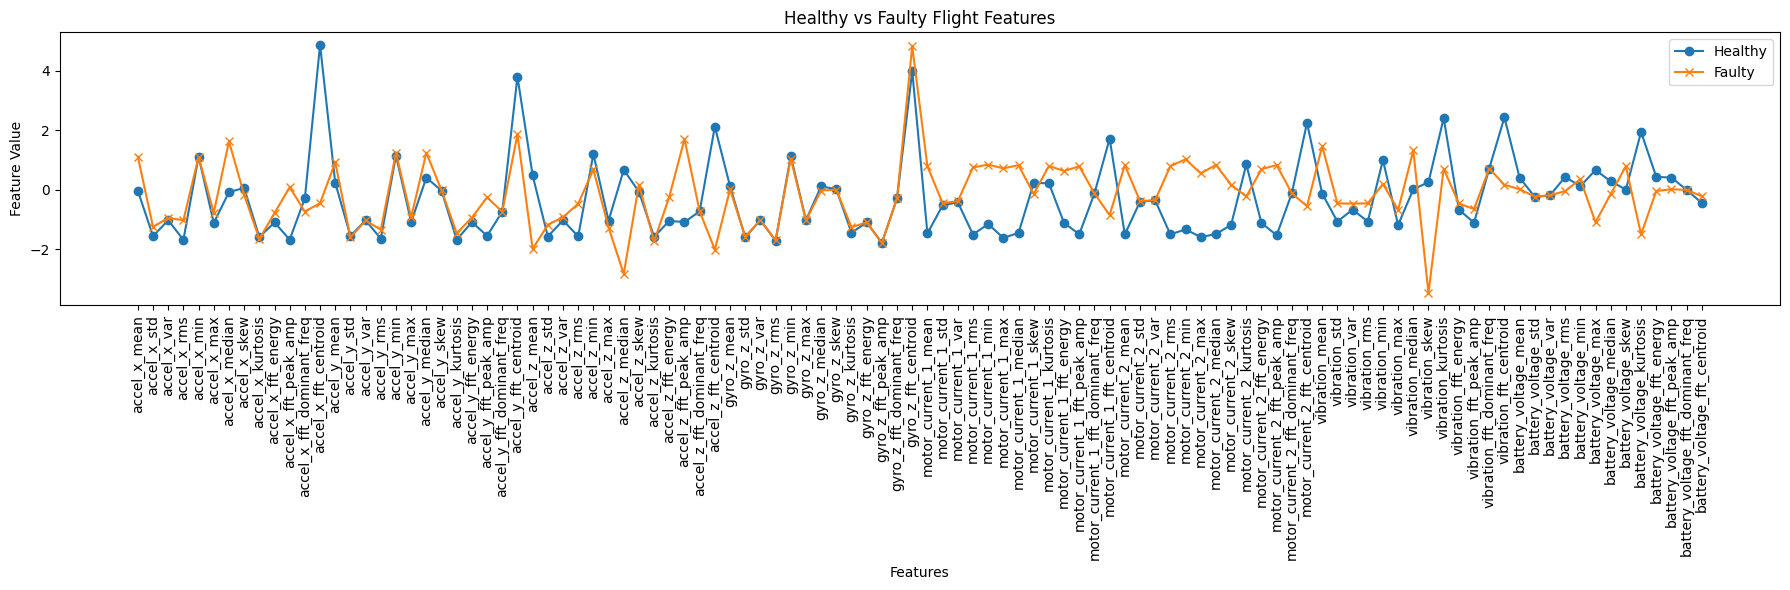

In [78]:

string_features=["flight_id", "failure_within_horizon","drone_id"]
features_to_scale = signal_features.columns.drop(["flight_id", "failure_within_horizon","drone_id"]) # column names
feature_scaled_arr=scaler.fit_transform(signal_features[features_to_scale])
feature_scaled_df = pd.DataFrame(
    feature_scaled_arr, 
    columns=features_to_scale, 
    index=signal_features.index
)
signal_features_scaled=pd.concat([signal_features[string_features], feature_scaled_df], axis=1)
healthy = signal_features_scaled[signal_features_scaled["failure_within_horizon"] == 0].iloc[0]
faulty = signal_features_scaled[signal_features_scaled["failure_within_horizon"] == 1].iloc[0]


import matplotlib.pyplot as plt

plt.figure(figsize=(18,6))

plt.plot(feature_cols, healthy[feature_cols], marker='o', label='Healthy')
plt.plot(feature_cols, faulty[feature_cols], marker='x', label='Faulty')

plt.xticks(rotation=90)
plt.xlabel("Features")
plt.ylabel("Feature Value")
plt.title("Healthy vs Faulty Flight Features")
plt.legend()

plt.tight_layout()
plt.show()

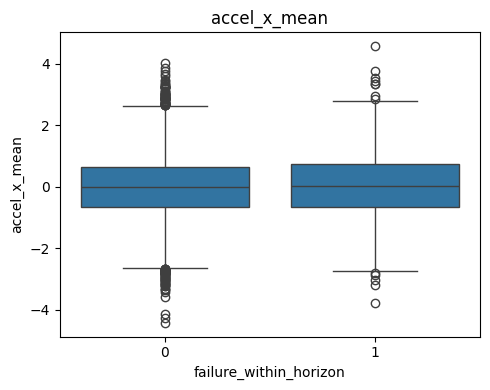

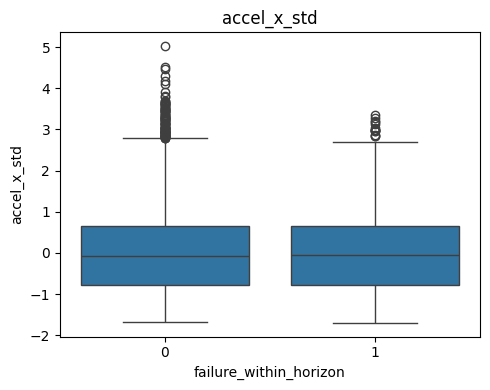

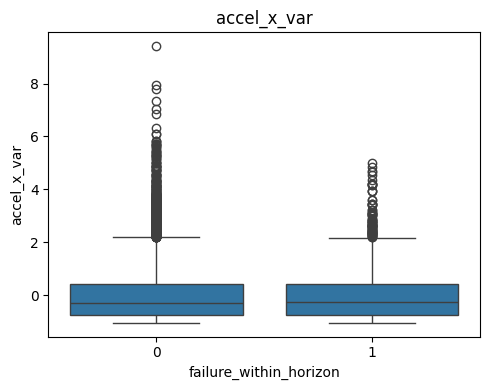

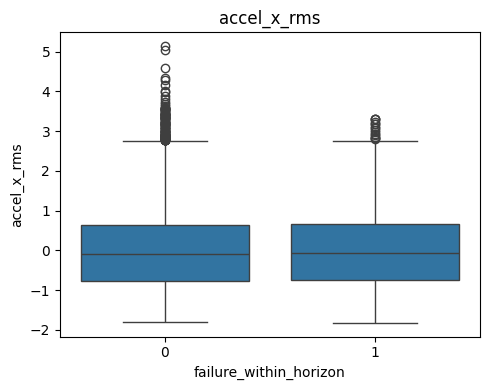

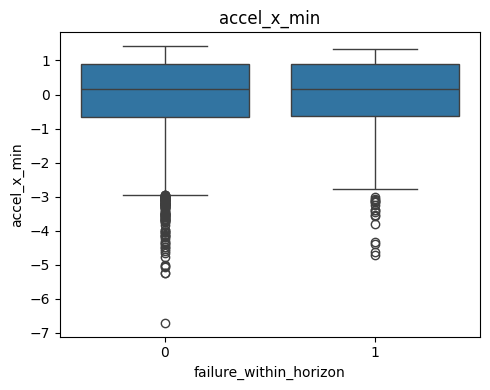

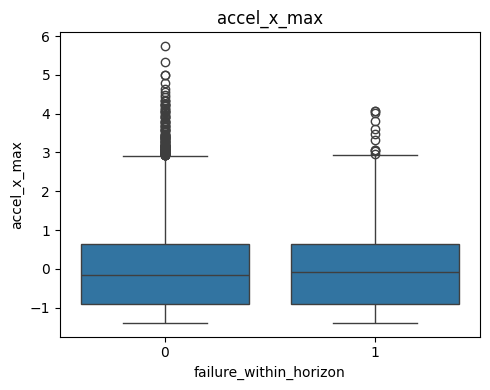

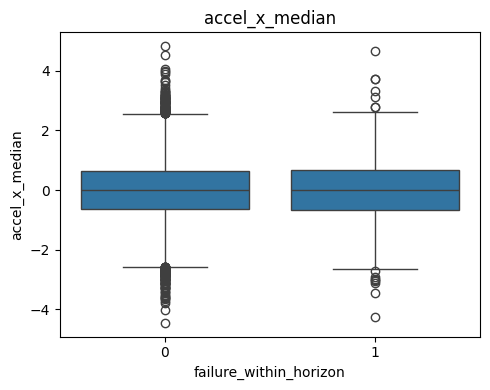

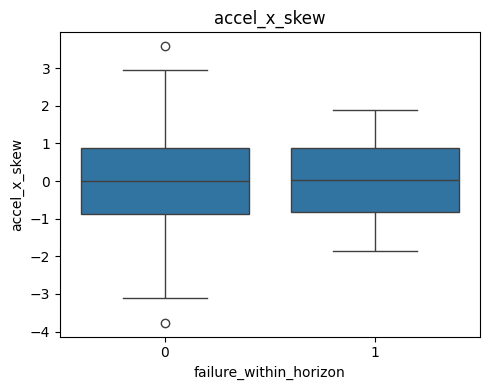

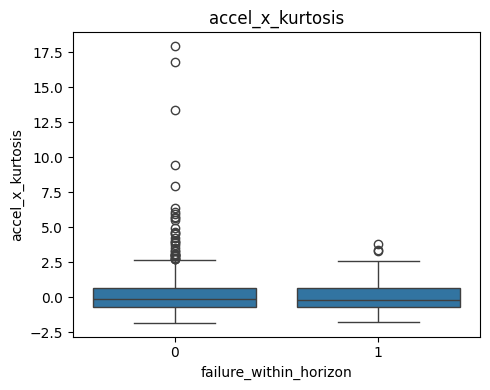

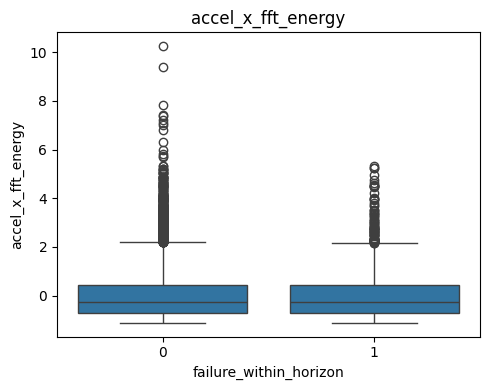

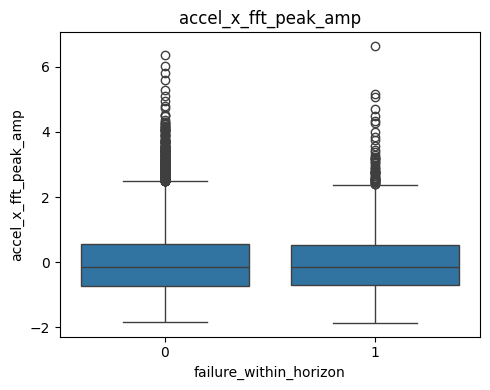

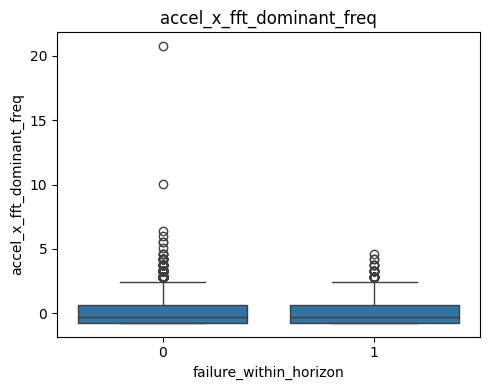

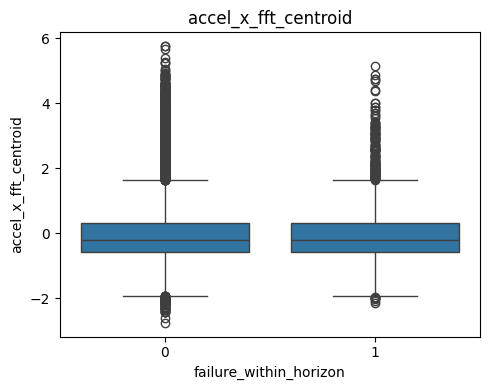

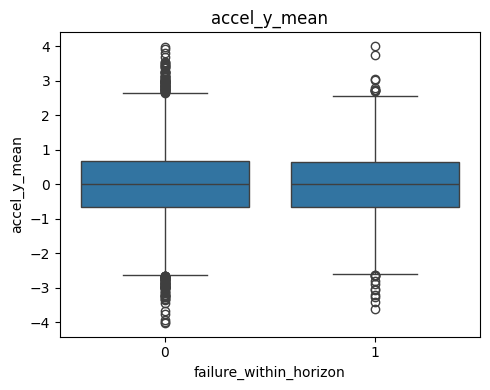

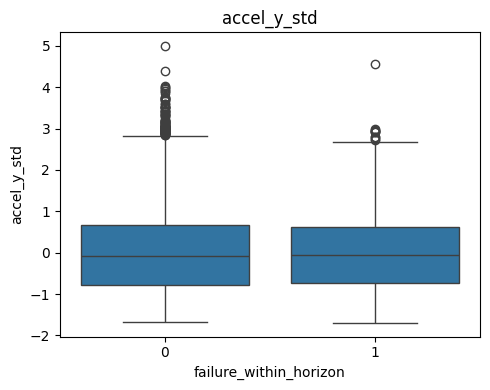

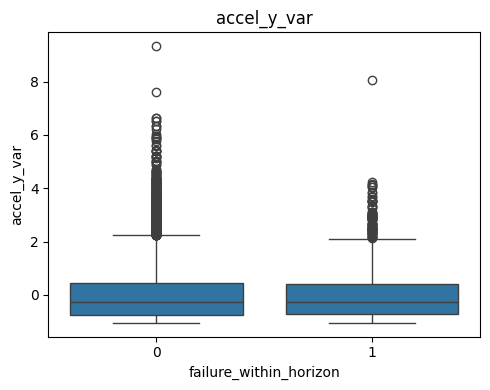

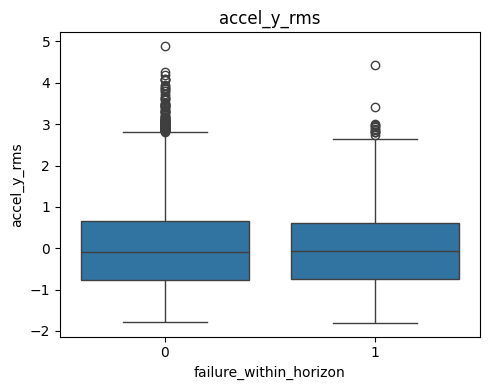

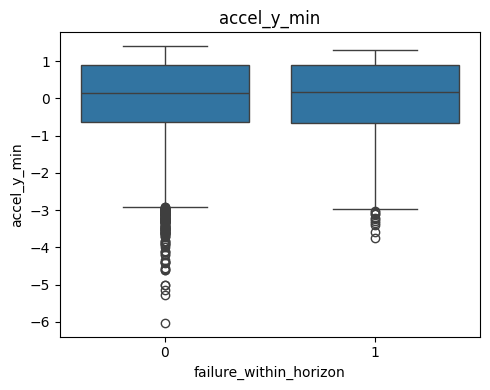

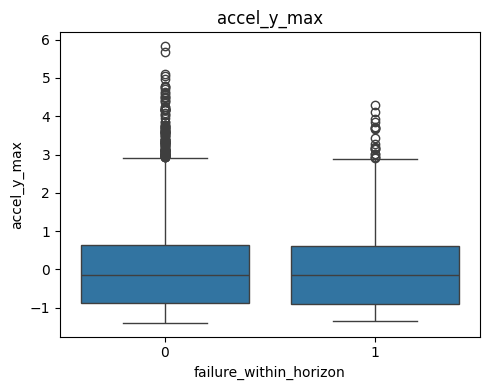

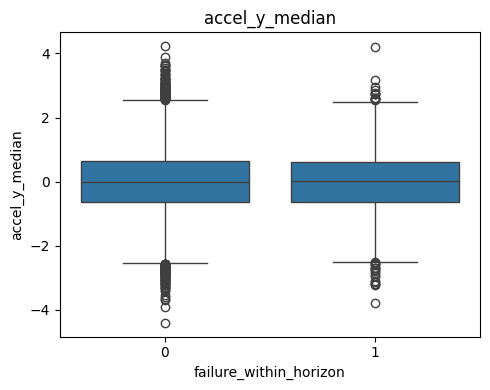

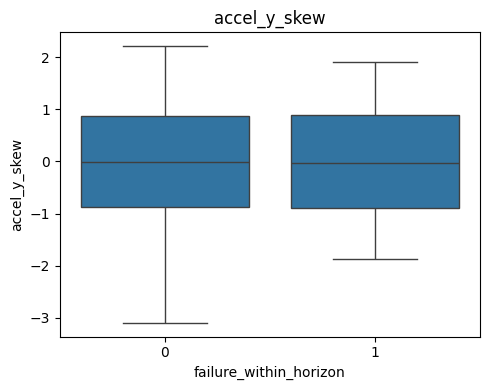

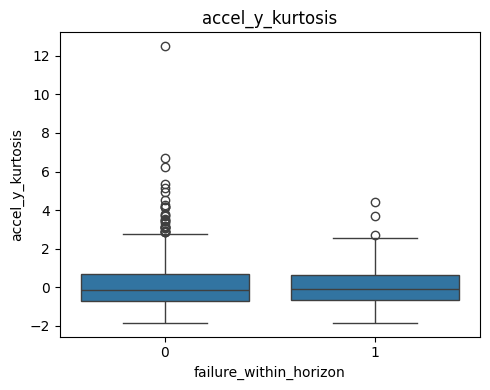

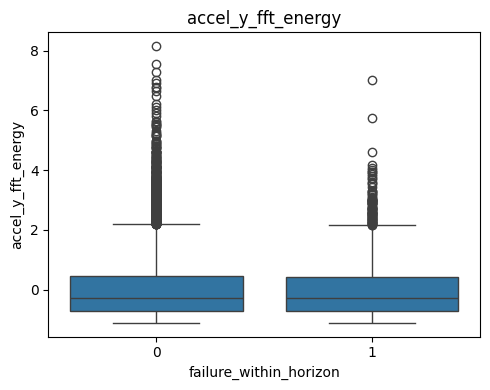

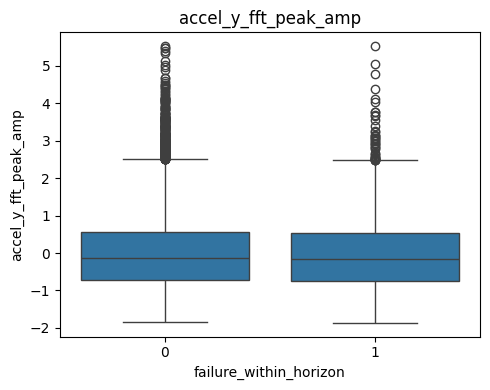

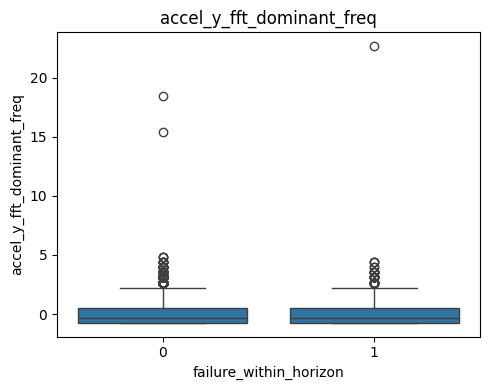

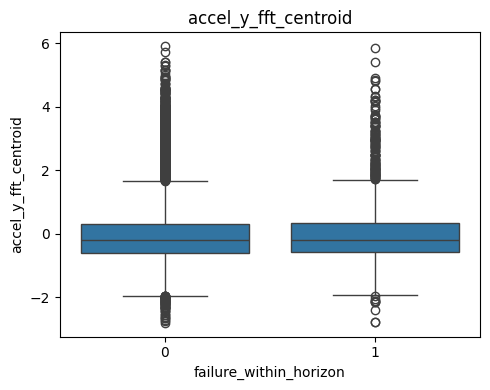

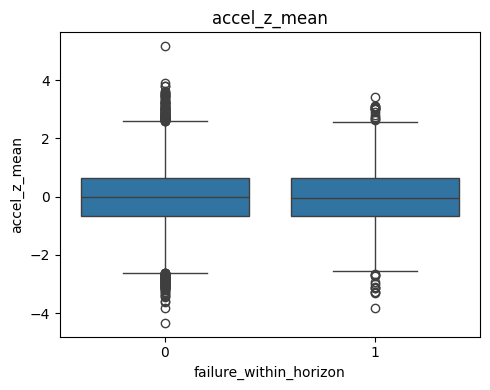

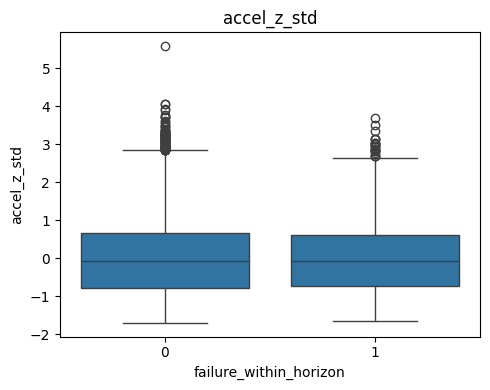

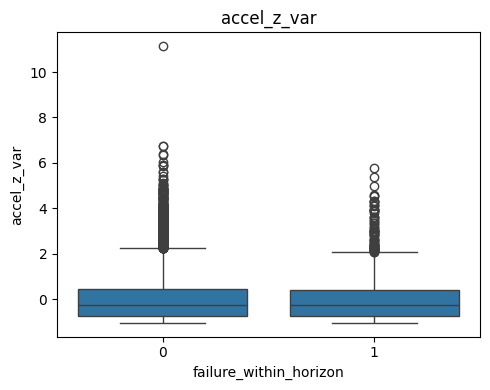

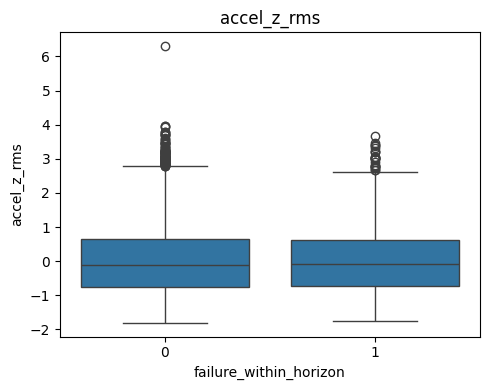

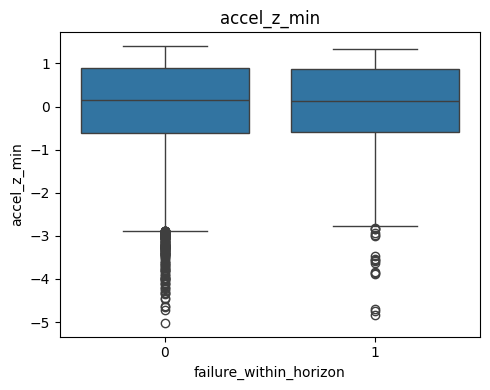

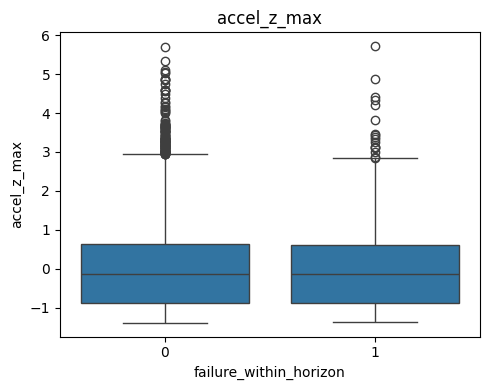

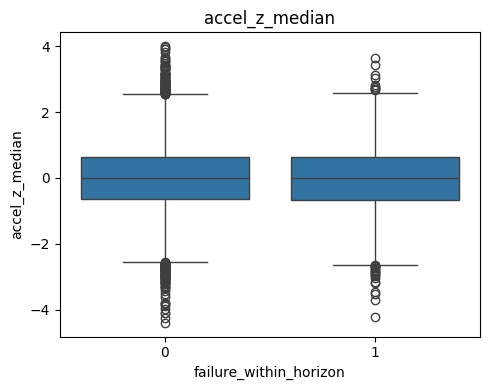

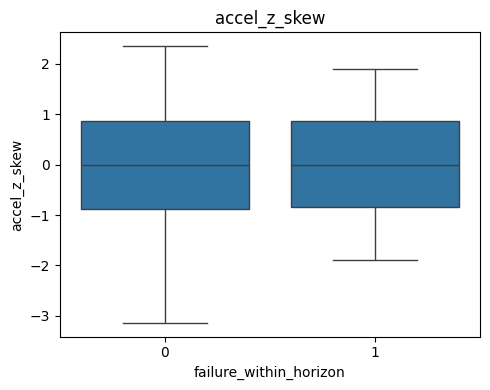

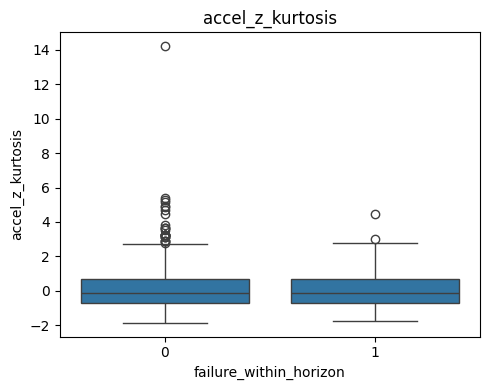

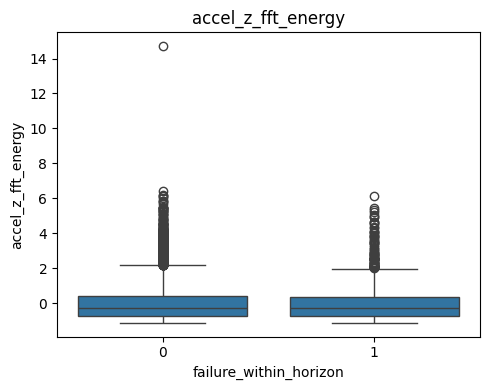

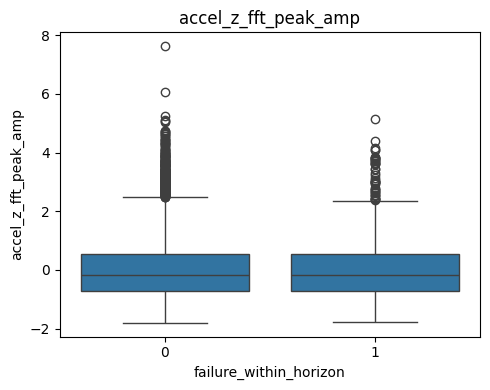

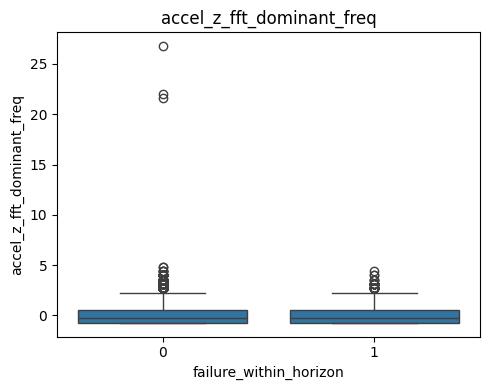

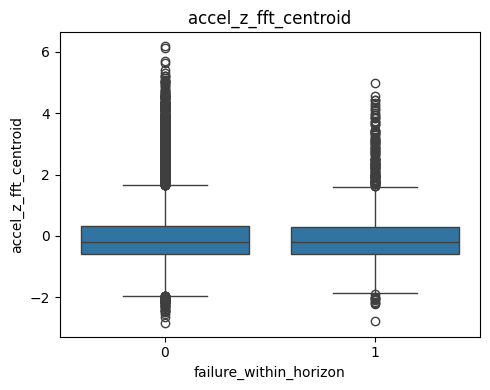

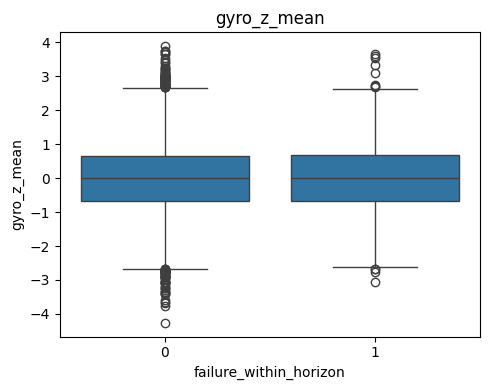

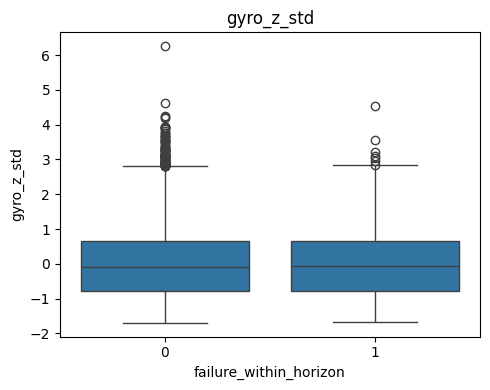

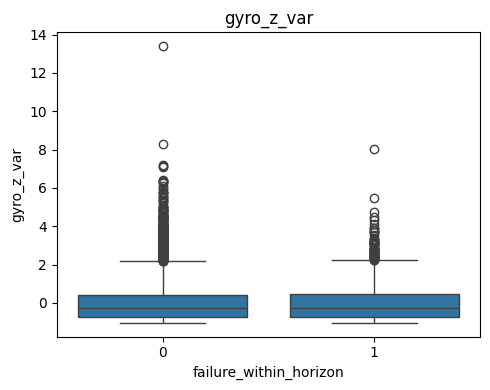

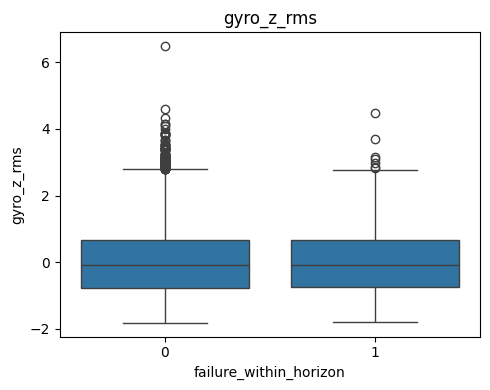

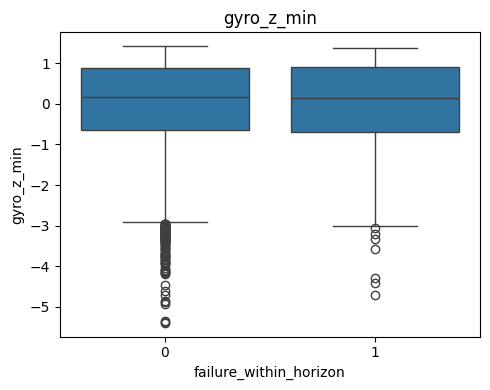

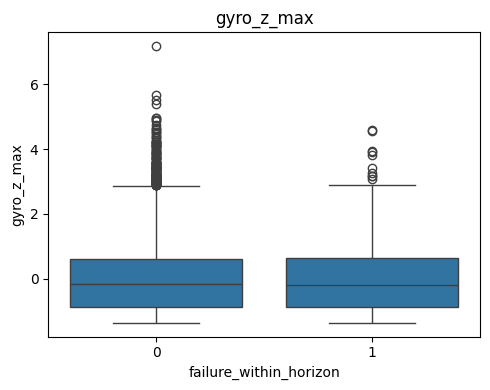

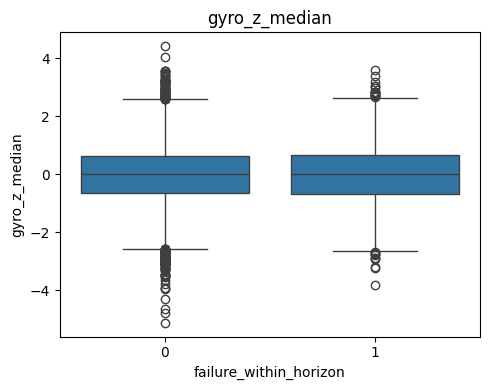

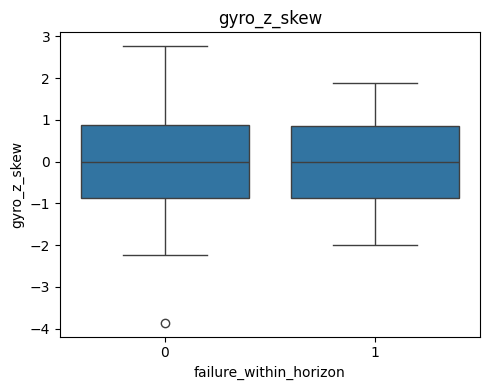

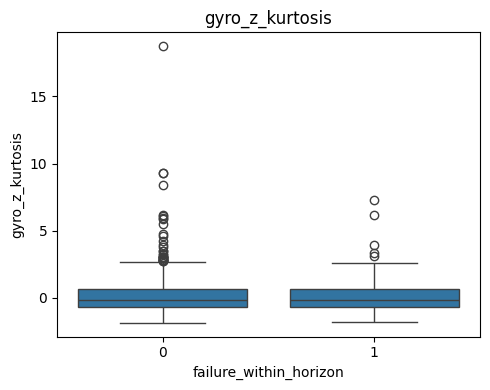

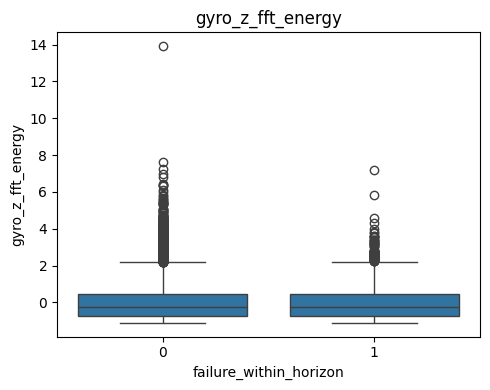

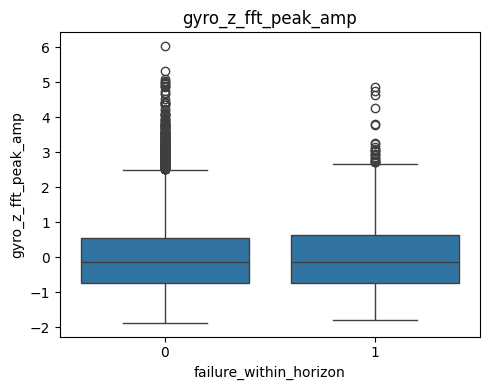

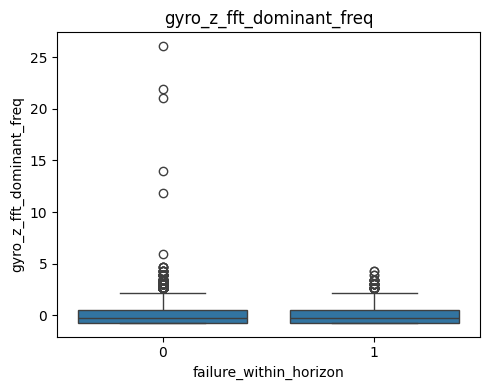

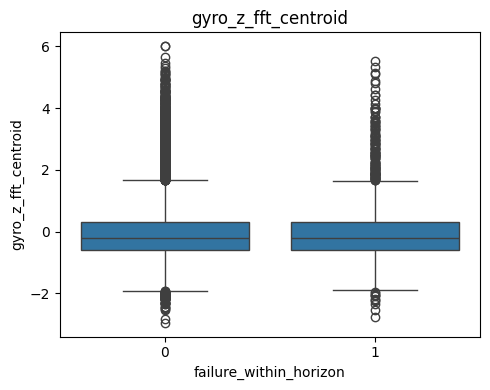

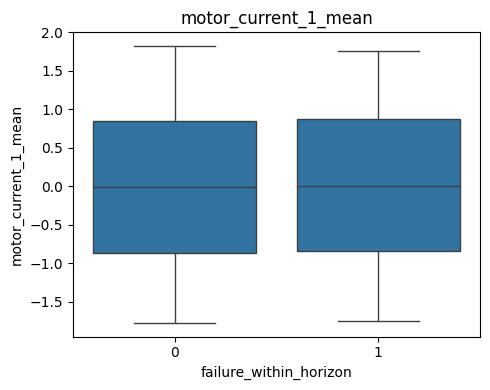

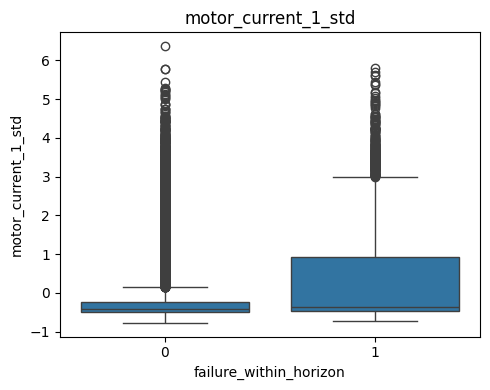

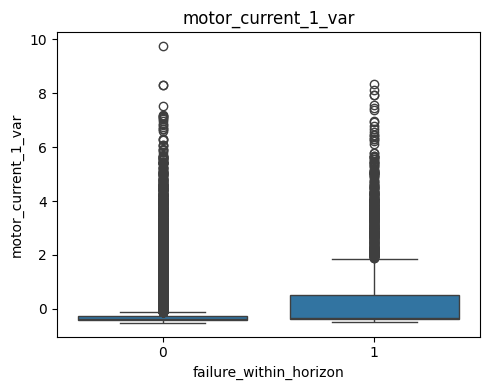

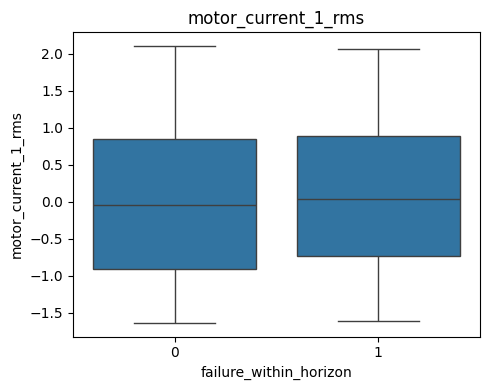

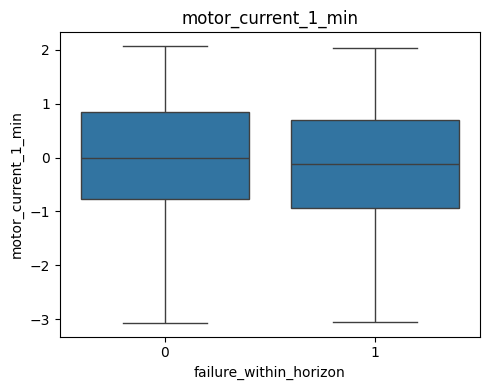

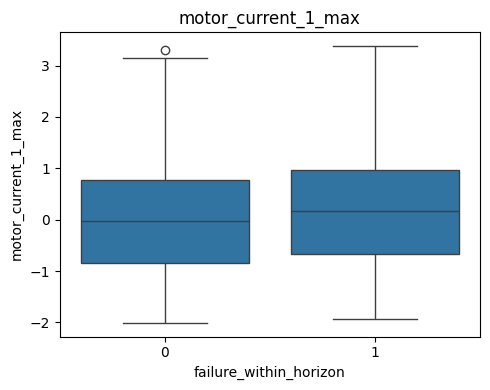

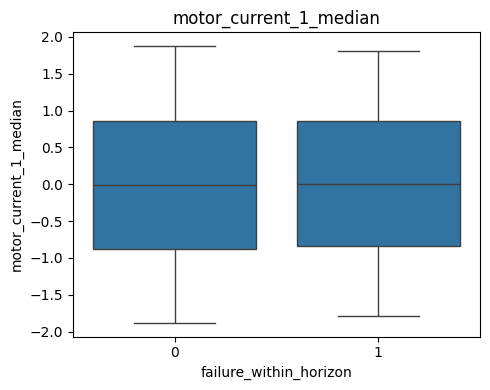

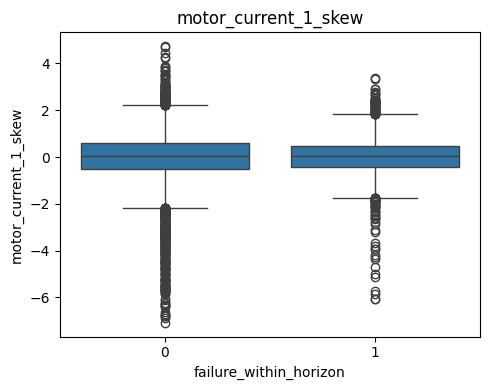

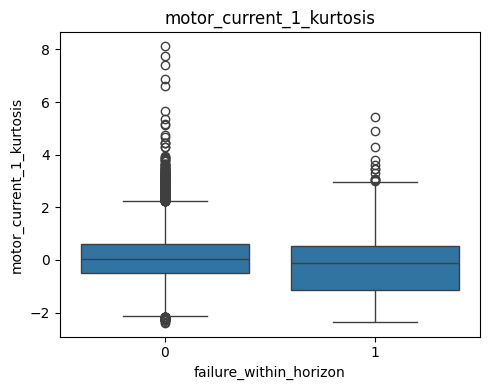

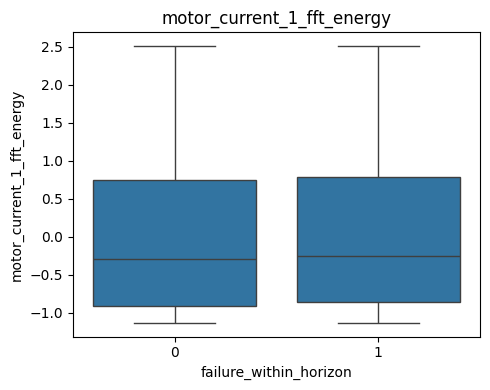

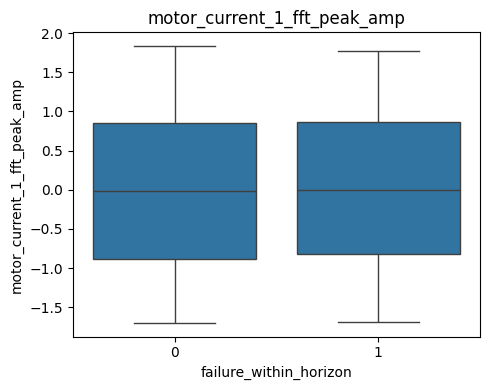

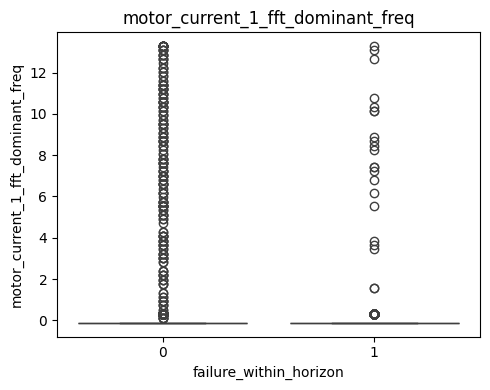

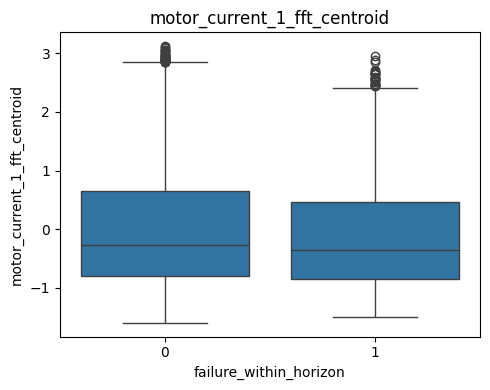

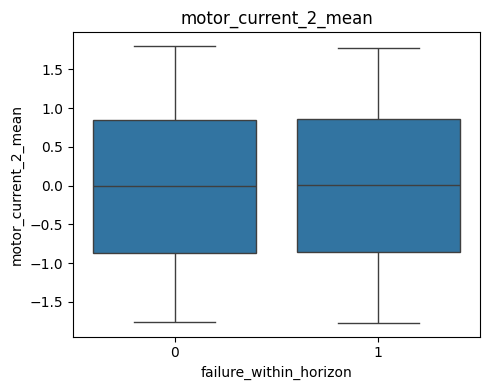

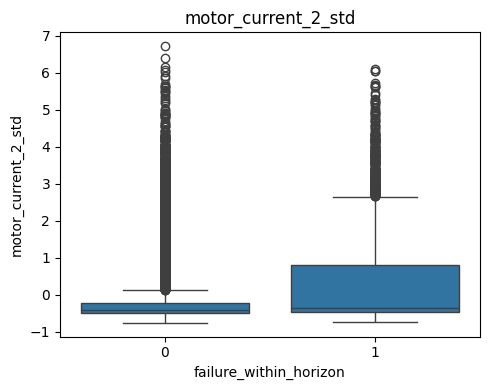

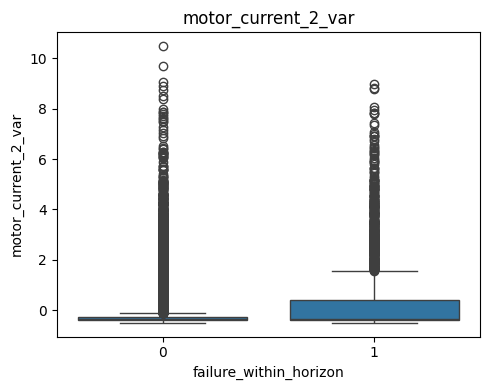

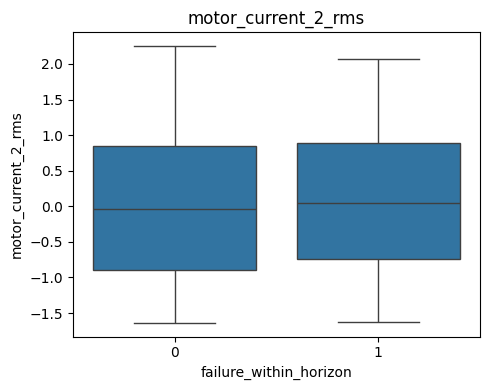

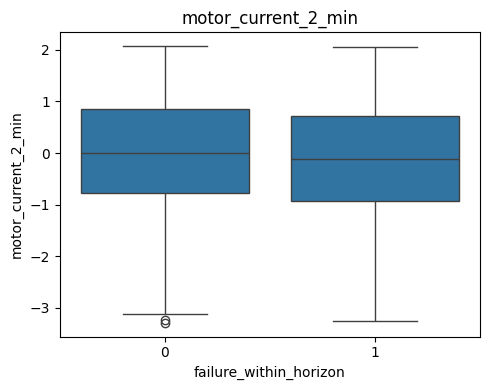

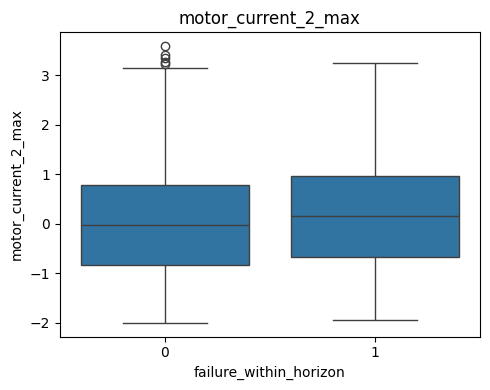

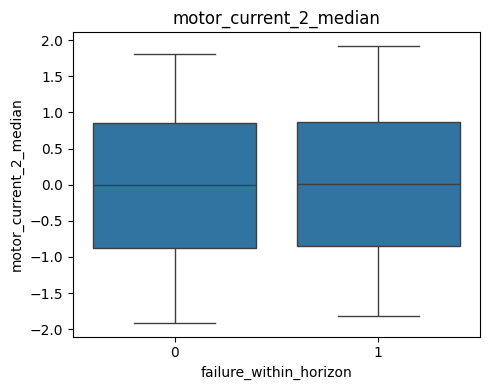

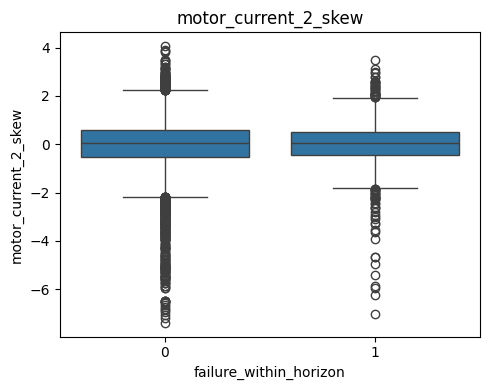

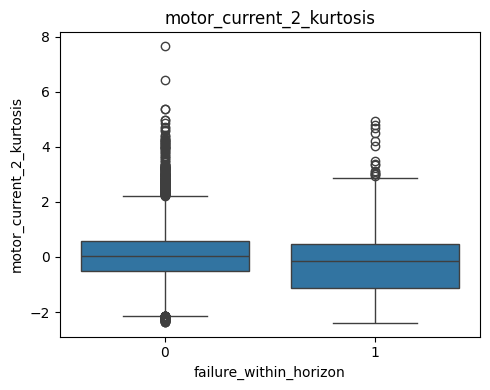

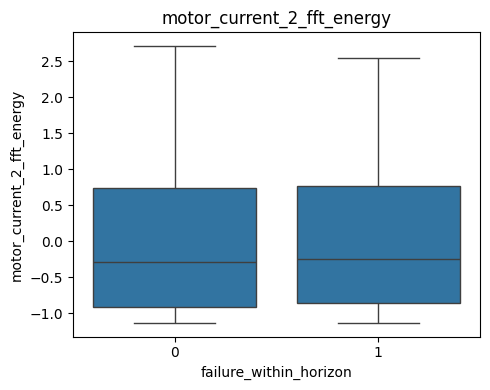

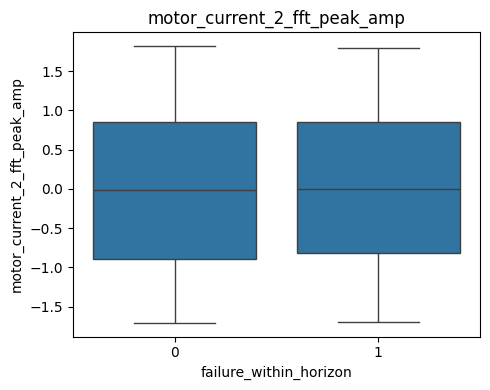

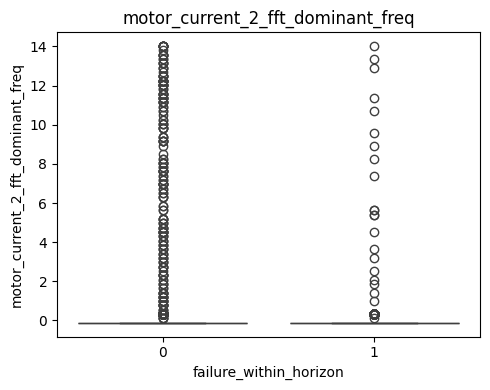

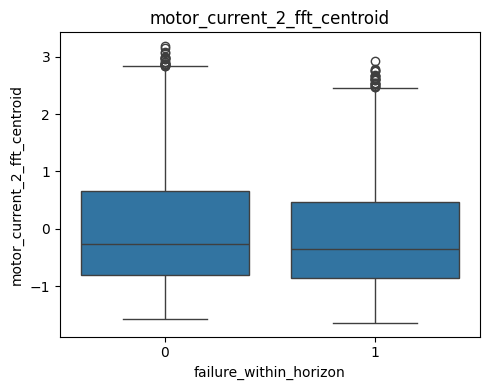

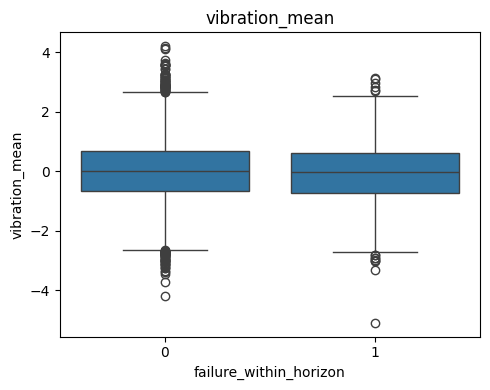

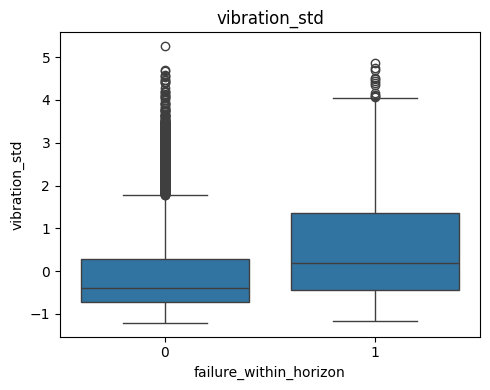

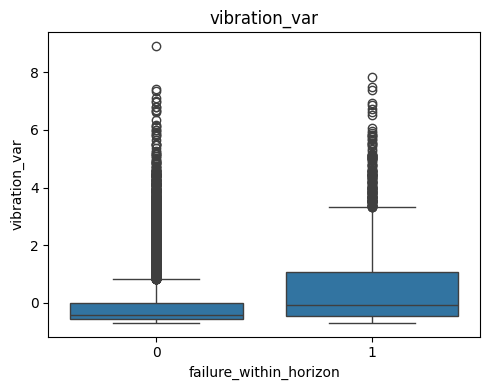

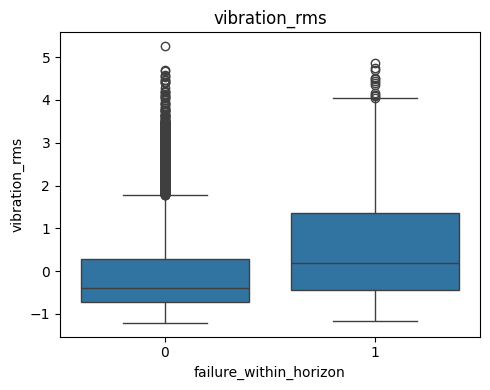

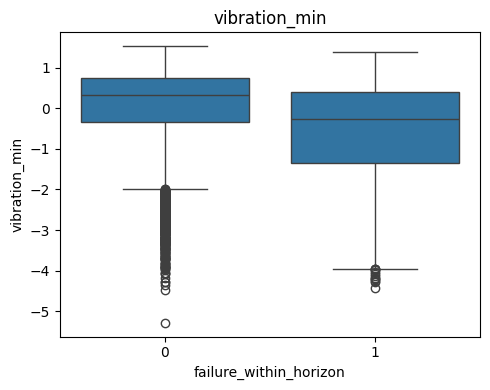

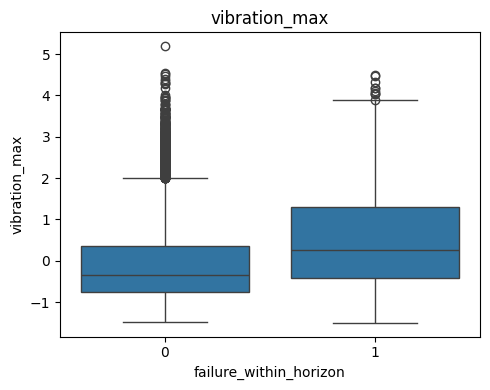

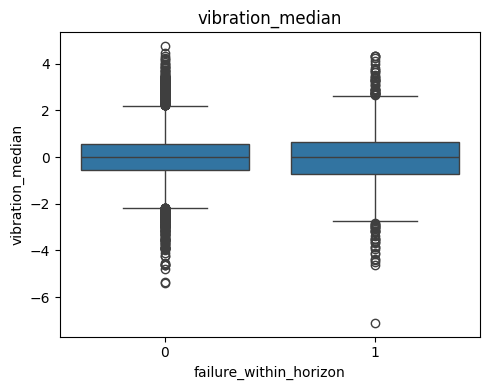

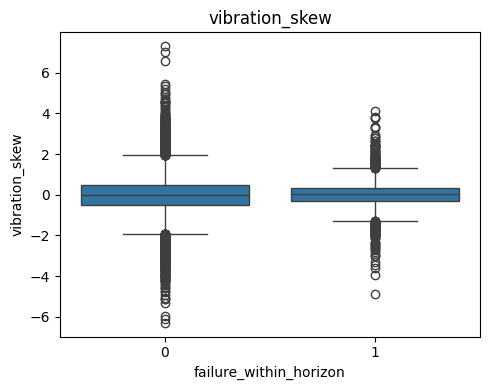

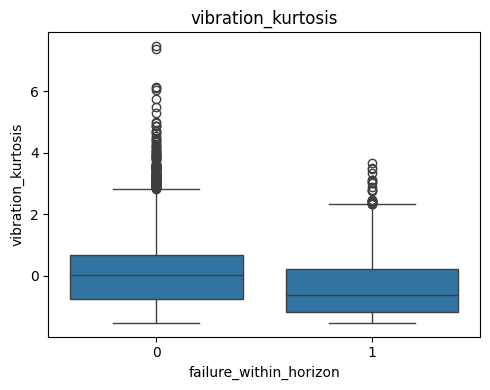

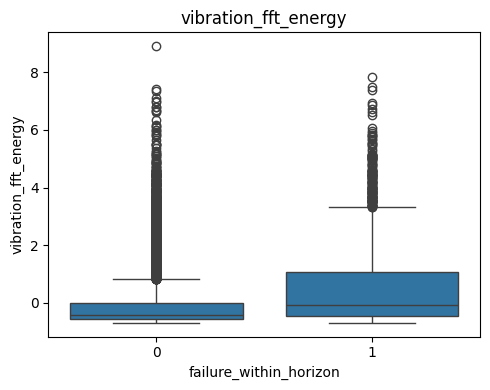

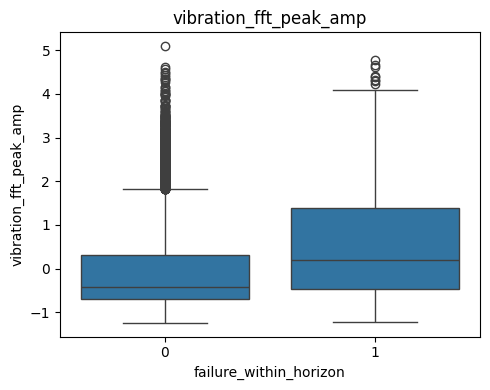

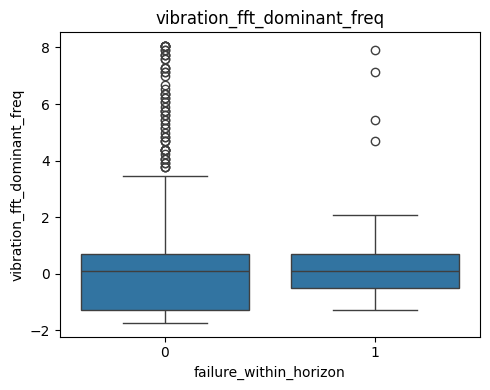

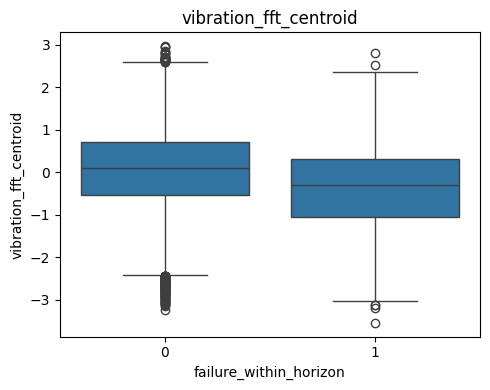

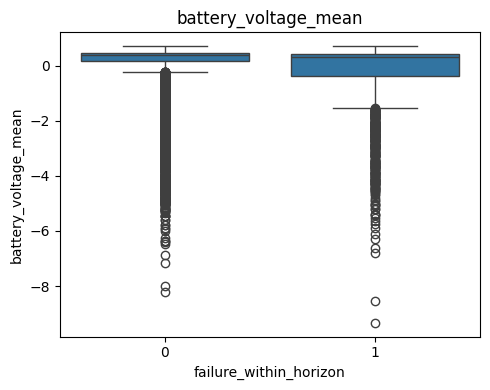

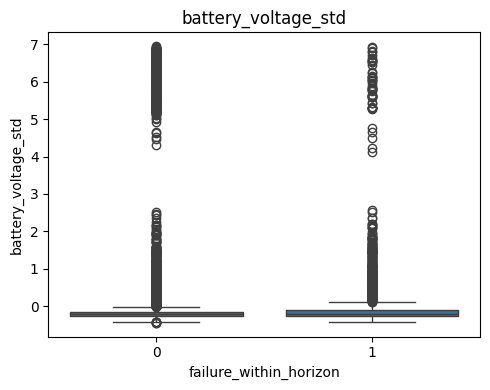

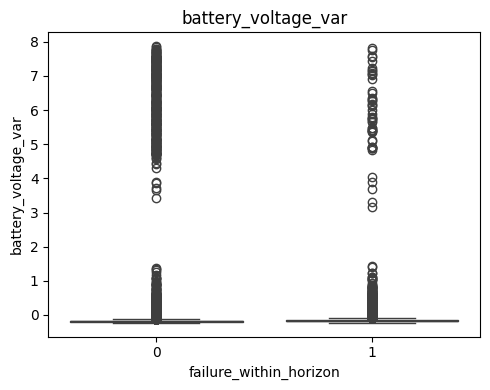

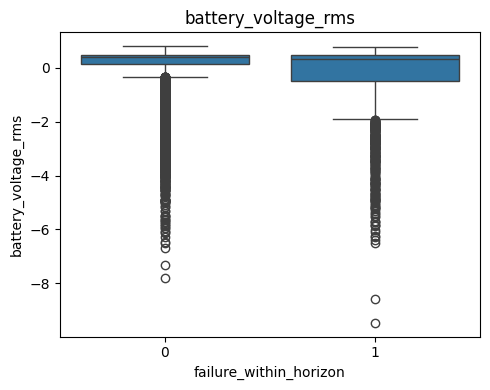

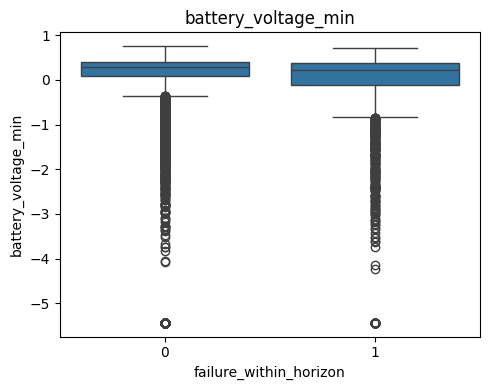

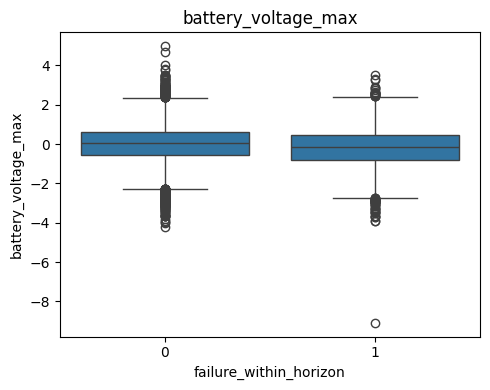

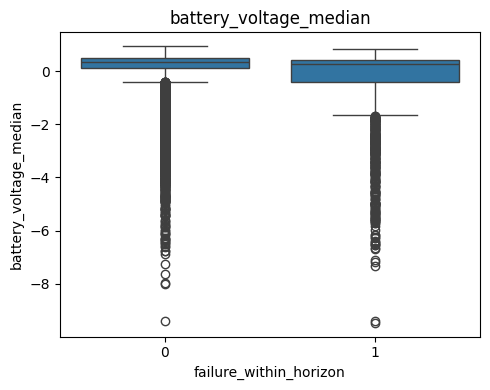

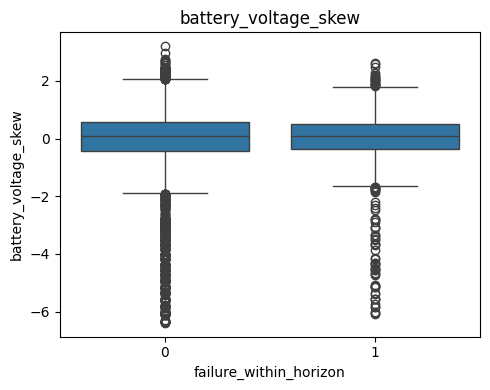

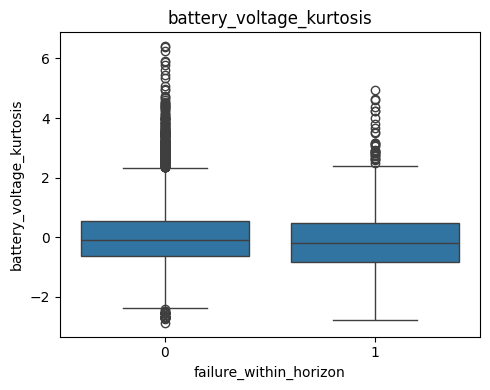

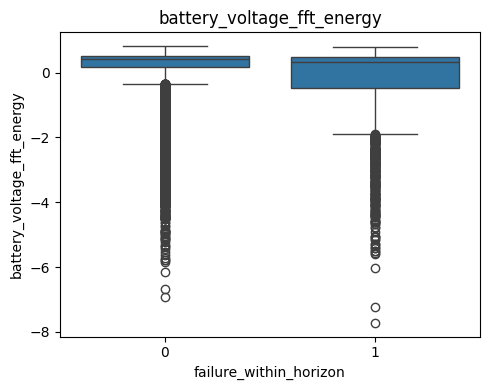

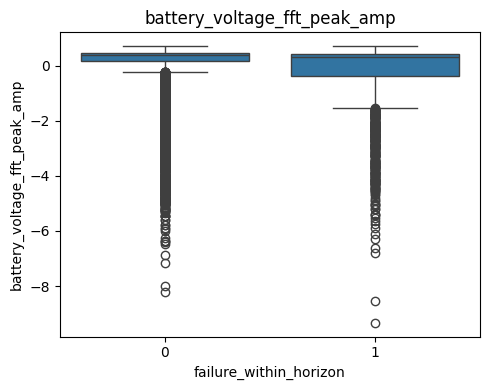

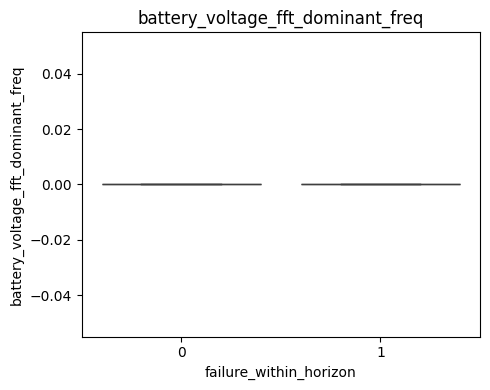

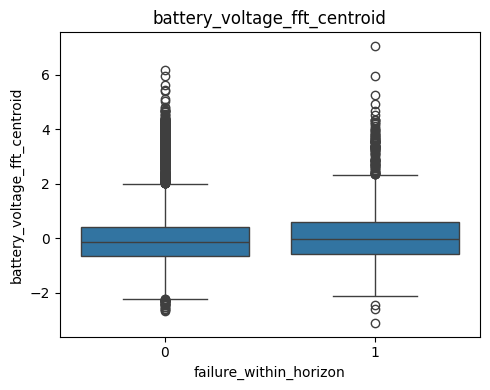

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in signal_features_scaled.columns:
    if col in ["flight_id", "drone_id", "failure_within_horizon"]:
        continue

    plt.figure(figsize=(5, 4))

    sns.boxplot(
        data=signal_features_scaled,
        x="failure_within_horizon",
        y=col
    )

    plt.title(col)
    plt.tight_layout()
    plt.show()

In [81]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, GroupKFold
gkf=GroupKFold(n_splits=6)
groups = signal_features["drone_id"]
lr=LogisticRegression(max_iter=1000,
    random_state=42)
scores = cross_val_score(
    lr,
    X_scaled,
    signal_features["failure_within_horizon"],
    cv=gkf,
    groups=groups,
    scoring="average_precision"
)
print("Fold scores:", scores)
print("Mean AUPRC:", scores.mean())

Fold scores: [0.27172915 0.30723574 0.26653716 0.30240068 0.31039138 0.27772188]
Mean AUPRC: 0.28933599715289


In [82]:
lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(X_scaled, signal_features["failure_within_horizon"])

coef = pd.Series(
    lr.coef_[0],
    index=X.columns
)

print(coef.sort_values(ascending=False).head(10))
print(coef.sort_values().head(10))

motor_current_1_rms           1.348659
gyro_z_rms                    0.725650
motor_current_2_rms           0.718859
vibration_rms                 0.523388
vibration_std                 0.518947
motor_current_1_fft_energy    0.478988
vibration_fft_peak_amp        0.421531
motor_current_1_var           0.383631
battery_voltage_std           0.382158
accel_y_std                   0.339334
dtype: float64
motor_current_1_median       -0.939055
gyro_z_std                   -0.714178
motor_current_2_fft_energy   -0.587946
battery_voltage_fft_energy   -0.562069
battery_voltage_var          -0.518701
motor_current_2_mean         -0.368664
accel_y_var                  -0.364171
motor_current_1_mean         -0.337616
battery_voltage_rms          -0.330212
motor_current_1_std          -0.320963
dtype: float64


In [83]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import average_precision_score

dt=DecisionTreeClassifier(random_state=42)
scores = cross_val_score(
    dt,
    X_scaled,
    signal_features["failure_within_horizon"],
    cv=gkf,
    groups=groups,
    scoring="average_precision"
)
print("Fold scores:", scores)
print("Mean AUPRC:", scores.mean())


Fold scores: [0.1209487  0.1338225  0.12620427 0.14875528 0.1443784  0.15562654]
Mean AUPRC: 0.13828928149001793


In [84]:
from sklearn.ensemble import RandomForestClassifier
gkf = GroupKFold(n_splits=6)

groups = signal_features["drone_id"]   

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

scores = cross_val_score(
    rf,
    X_scaled,
    signal_features["failure_within_horizon"],
    cv=gkf,
    groups=groups,
    scoring="average_precision"
)

print("Fold scores:", scores)
print("Mean AUPRC:", scores.mean())

Fold scores: [0.26317541 0.33005134 0.26408544 0.28538254 0.27866079 0.27534778]
Mean AUPRC: 0.2827838838604577


In [85]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_scaled, signal_features["failure_within_horizon"])

importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance.head(20))

motor_current_1_std           0.021209
motor_current_1_var           0.018650
motor_current_2_var           0.016160
vibration_max                 0.016079
vibration_var                 0.016072
vibration_rms                 0.016032
motor_current_2_kurtosis      0.015452
motor_current_2_std           0.014806
vibration_fft_energy          0.014694
motor_current_1_kurtosis      0.014554
vibration_std                 0.014478
battery_voltage_median        0.014346
vibration_fft_peak_amp        0.013904
vibration_min                 0.013572
vibration_kurtosis            0.013151
motor_current_1_skew          0.011987
vibration_median              0.011912
battery_voltage_fft_energy    0.011631
accel_z_skew                  0.011514
battery_voltage_kurtosis      0.011427
dtype: float64
